# SWIM distance and logical gap: saved-data comparison

Load a completed canonical YAML run and compare saved SWIM distance and complementary logical gap. Each plotted series uses its own decoder's `logical_error.parquet`; the comparison does not assume that different decoder points share sampled shots. The SWIM score is the minimum original-prior stage-2 distance among candidates in the selected logical class. Supported SWIM points are one-round triangular data-only bit-flip memory and validated closed triangular `rounds=d` Z-memory.

The three views follow the scatter conventions of `circuit_level_swim_selection_strategies.ipynb`: outcome frequencies, conditional logical error probability, and post-selection with 99% Wilson bands. No fitted calibration curve is overlaid.


In [1]:
from pathlib import Path
import importlib
import subprocess
import matplotlib.pyplot as plt
from IPython.display import display
import color_code_softoutput.analysis.workflow_soft_output as workflow_soft_output
importlib.reload(workflow_soft_output)
WorkflowSoftOutputRun = workflow_soft_output.WorkflowSoftOutputRun

# Resolve data paths from the repository root, even when the kernel starts
# in notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

run_directory = PROJECT_ROOT / "results/bitflip_swim/26_09_30_17_48_23_a219af0b"
run = WorkflowSoftOutputRun(run_directory)
run.run.catalog


,source_run,source_priority,data_directory,decoder_alias,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,5,1,0.02,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True
1,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,5,1,0.02,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True
2,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,5,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True
3,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,5,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True
4,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,7,1,0.02,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True
5,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,7,1,0.02,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True
6,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True
7,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True
8,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,9,1,0.02,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True
9,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,9,1,0.02,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True


## Choose conditions, metrics and grouping

`filters` selects experiment points. `groups` creates separate plotted series; metrics are always separate, even if omitted from `groups`. Include `distance` whenever multiple distances are selected. SWIM distance uses a blue base hue and logical gap a red base hue; within each hue, larger code distance is darker and uses a different marker. A given distance uses the same marker for both metrics. Decoder type controls marker size only when more than one type is present, and its legend is then created automatically. A one-field tuple needs a comma: `("decoder_type",)`; a list is easier to edit.

`metrics=["swim_distance", "logical_gap"]` overlays both scores. It reads only the saved combinations: in this run `concat_mwpm` supplies logical gap, while `concat_mwpm_stage2_base` and `color_correlated` supply SWIM. The stage-2-base decoder uses a different final-selection weight from `concat_mwpm`. Every selected point must have at least one requested metric, and every requested metric must occur in the selection. `available_metrics` below shows which files exist.

`bins="auto"` preserves discrete scores when there are few distinct values; an integer such as 40 uses common histogram intervals across series. `round_digits` optionally rounds scores before grouping and post-selection ties. Distribution normalization divides each outcome count by all shots in its own series. `signed_logical_errors` affects only distribution display; selection and conditional rates use the original nonnegative scores. The size, axis scales/limits, typography, legend canvases and export formats below are notebook-level manuscript controls.


In [ ]:
filters = {
    "distane": [, 9],
    "physical_error_rate": [0.04],
    "decoder_type": ["concat_mwpm"],
}
groups = ["distance", "decoder_type"]
metrics = ["swim_distance", "logical_gap"]
bins = "auto"  # or 40 for shared histogram intervals
round_digits = 2
signed_logical_errors = True  # True: negate errors and keep the metric marker unchanged
normalize_frequency = False  # True: outcome counts / all shots in each series
distribution_yscale = "log"
conditional_yscale = "log"  # zero rates show Wilson shading only
postselection_yscale = "log"
postselection_xlim = (0, 1)
plot_width, plot_height = 6.4, 4.0  # main figure size in inches
figure_dpi = 300
save_figures = True
export_formats = ("pdf", "png")
legend_columns = {"distance": 5, "metric": 2, "decoder_type": 3, "logical_error": 2}
legend_options = dict(fontsize=10, row_height=0.35, width=3.0,
                      ncol=legend_columns, frame_linewidth=0.6)

def manuscript_axes():
    figure, axes = plt.subplots(figsize=(plot_width, plot_height), dpi=figure_dpi)
    axes.tick_params(direction="in", which="both", top=True, right=True)
    return figure, axes

run.available_metrics(filters)


,source_run,source_priority,data_directory,decoder_alias,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available,swim_distance_available,logical_gap_available
0,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,5,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True,False,True
1,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,5,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True,True,False
2,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True,False,True
3,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True,True,False
4,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,9,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True,False,True
5,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,9,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True,True,False
6,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,11,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True,False,True
7,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,11,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True,True,False
8,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_comparative,concat_mwpm,tri,13,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_comparative,decoder_...",True,False,True
9,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,concat_mwpm_swim,concat_mwpm,tri,13,1,0.04,bitflip,tri_optimal,100000,"decoder_alias=concat_mwpm_swim,decoder_type=co...",True,True,False


## Distribution

Points show counts or normalized frequencies at grouped score values. Blue identifies SWIM distance, red identifies logical gap, and darker shades plus marker shape identify larger code distances. With `signed_logical_errors=True`, logical-error scores are negated and use exactly the same distance marker as successes; no error `x` is introduced. With `False`, errors are hollow and successes filled. Saved scores are never modified.


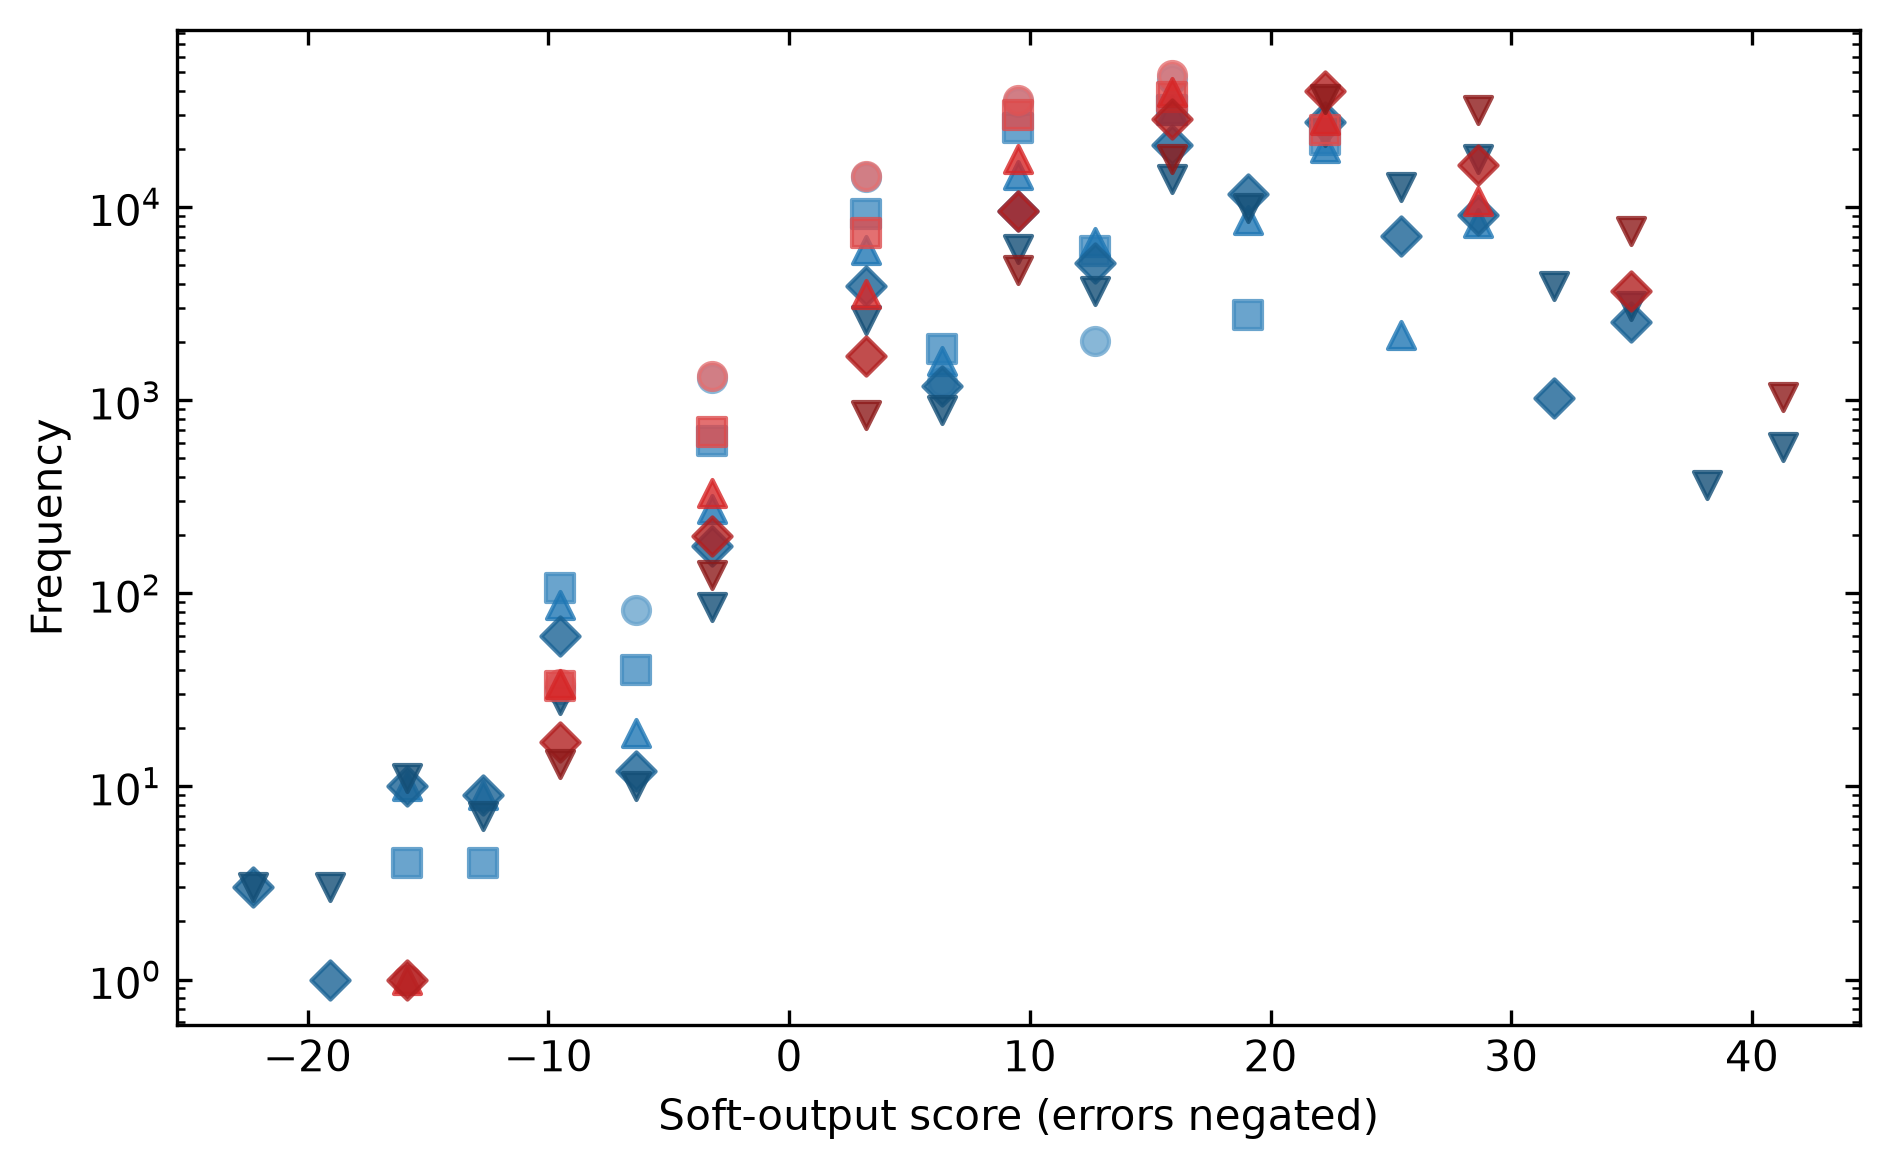

,score,raw_score,logical_error,count,shots,failures,frequency,density,total_shots,signed_logical_errors,bin_left,bin_right,distance,decoder_type,metric
0,3.18,3.18,False,14244,14244,0,14244,14244,100000,True,3.18,3.18,5,concat_mwpm,swim_distance
1,6.36,6.36,False,1241,1241,0,1241,1241,100000,True,6.36,6.36,5,concat_mwpm,swim_distance
2,9.53,9.53,False,34969,34969,0,34969,34969,100000,True,9.53,9.53,5,concat_mwpm,swim_distance
3,12.71,12.71,False,2018,2018,0,2018,2018,100000,True,12.71,12.71,5,concat_mwpm,swim_distance
4,15.89,15.89,False,46115,46115,0,46115,46115,100000,True,15.89,15.89,5,concat_mwpm,swim_distance


In [3]:
fig_distribution, ax_distribution = manuscript_axes()
fig_distribution, distribution_table = run.plot_distribution(
    metrics=metrics, filter=filters, group_by=groups, bins=bins,
    signed_logical_errors=signed_logical_errors,
    normalize_frequency=normalize_frequency, round_digits=round_digits,
    yscale=distribution_yscale, ax=ax_distribution,
)
# Manuscript adjustments for this panel go here, for example:
# ax_distribution.set_xlim(-40, 40)
fig_distribution.tight_layout()
display(fig_distribution)
plt.close(fig_distribution)
distribution_table.head()


## Conditional logical error probability

The empirical probability in each score group is failures / shots. The shade is its 99% Wilson interval. SWIM uses blue and logical gap uses red; increasing code distance darkens each base hue and changes marker shape. Points from the same series are connected to make the trend visible. Zero-rate groups retain the band but have no plotted estimate, and the line is broken at those bins.


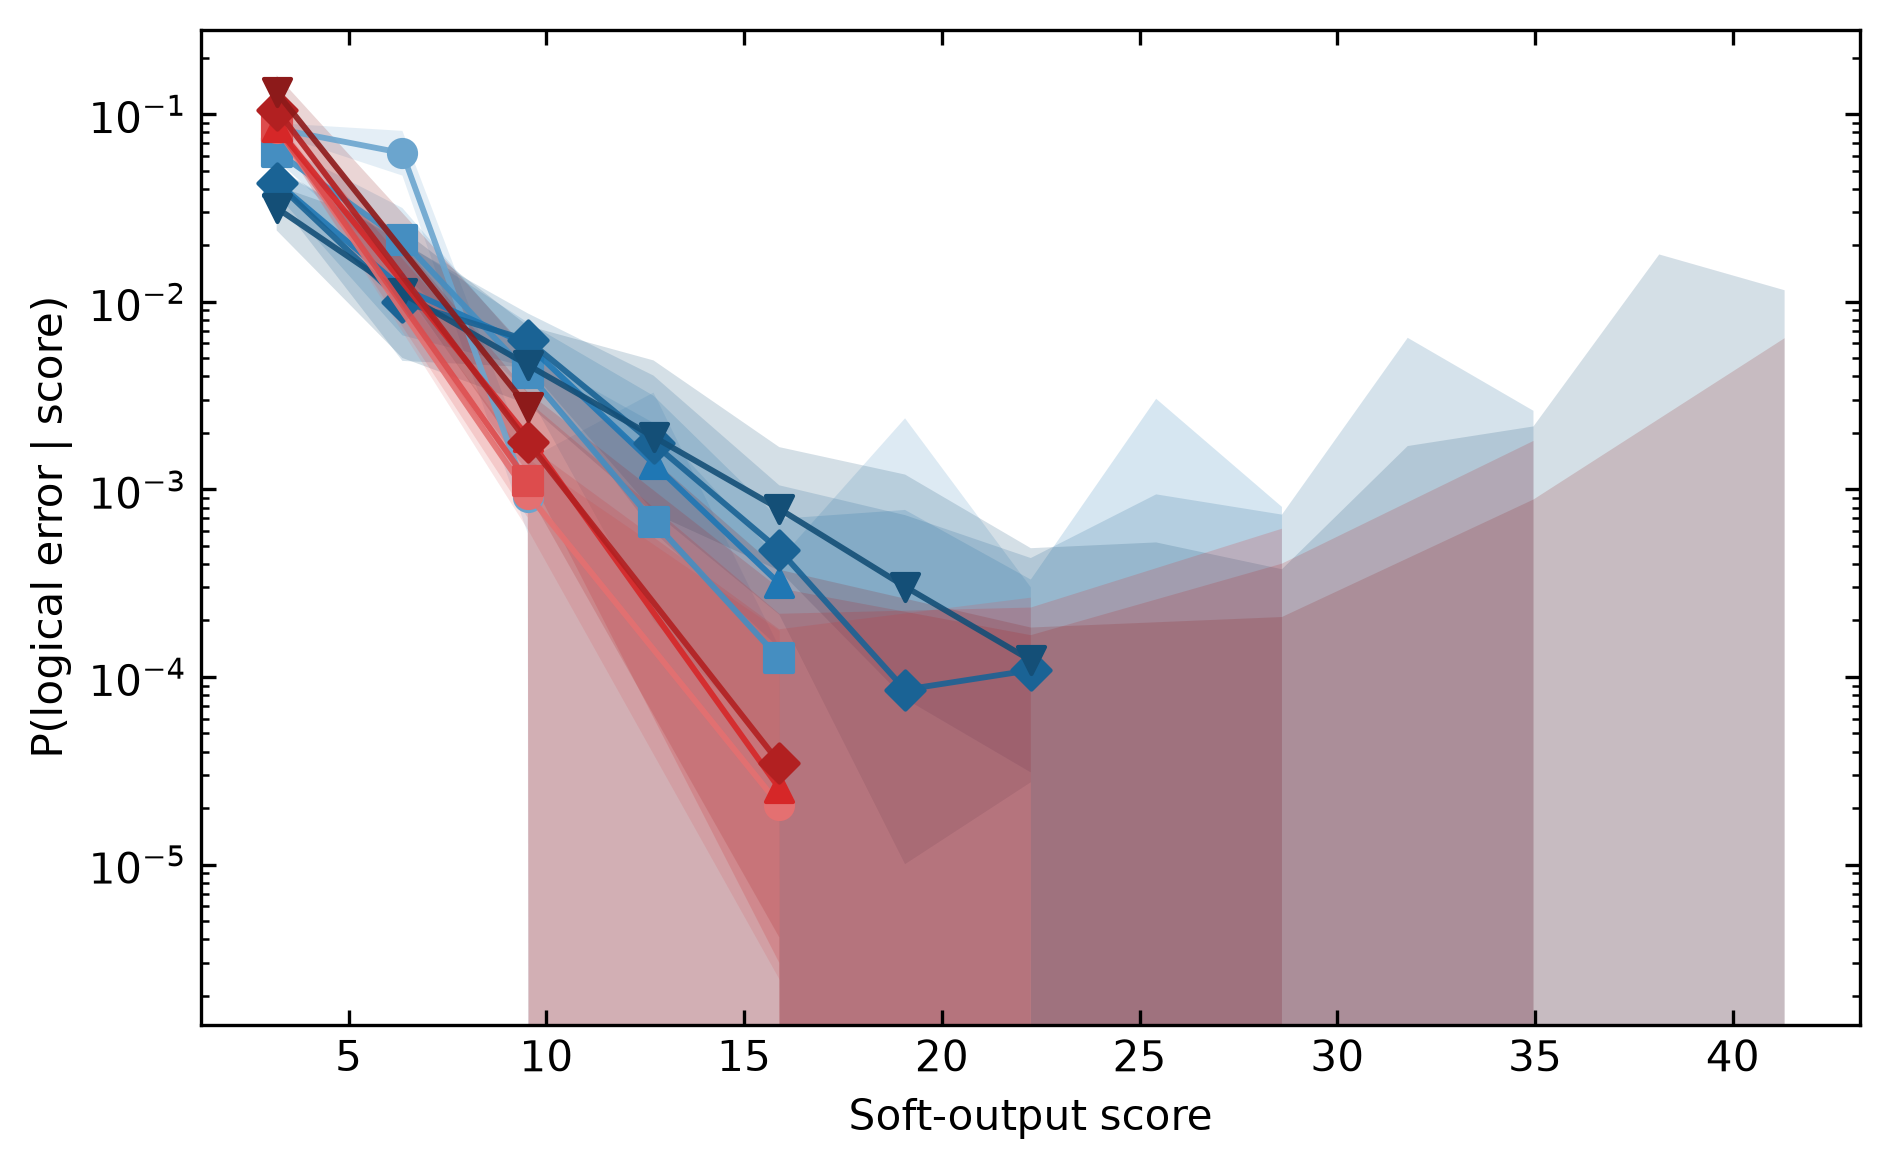

,score,shots,failures,logical_error_rate,low,high,distance,decoder_type,metric
0,3.18,15543,1299,0.083575,0.078033,0.089472,5,concat_mwpm,swim_distance
1,6.36,1323,82,0.061980,0.046994,0.081338,5,concat_mwpm,swim_distance
2,9.53,35001,32,0.000914,0.000582,0.001436,5,concat_mwpm,swim_distance
3,12.71,2018,0,0.000000,0.000000,0.003277,5,concat_mwpm,swim_distance
4,15.89,46115,0,0.000000,0.000000,0.000144,5,concat_mwpm,swim_distance


In [4]:
fig_conditional, ax_conditional = manuscript_axes()
fig_conditional, conditional_table = run.plot_conditional_ler(
    metrics=metrics, filter=filters, group_by=groups, bins=bins,
    round_digits=round_digits, yscale=conditional_yscale, ax=ax_conditional,
)
# ax_conditional.set_xlim(0, 40)
fig_conditional.tight_layout()
display(fig_conditional)
plt.close(fig_conditional)
conditional_table.head()


## Post-selection

Retain scores >= each threshold and reject lower scores. Each exact threshold gives a scatter point: rejected fraction versus the logical error rate among retained shots. The shade is a 99% Wilson interval on the retained rate, not an interval on the rejected fraction. Zero retained-error rates show only the band. Error-score negation is never used here.


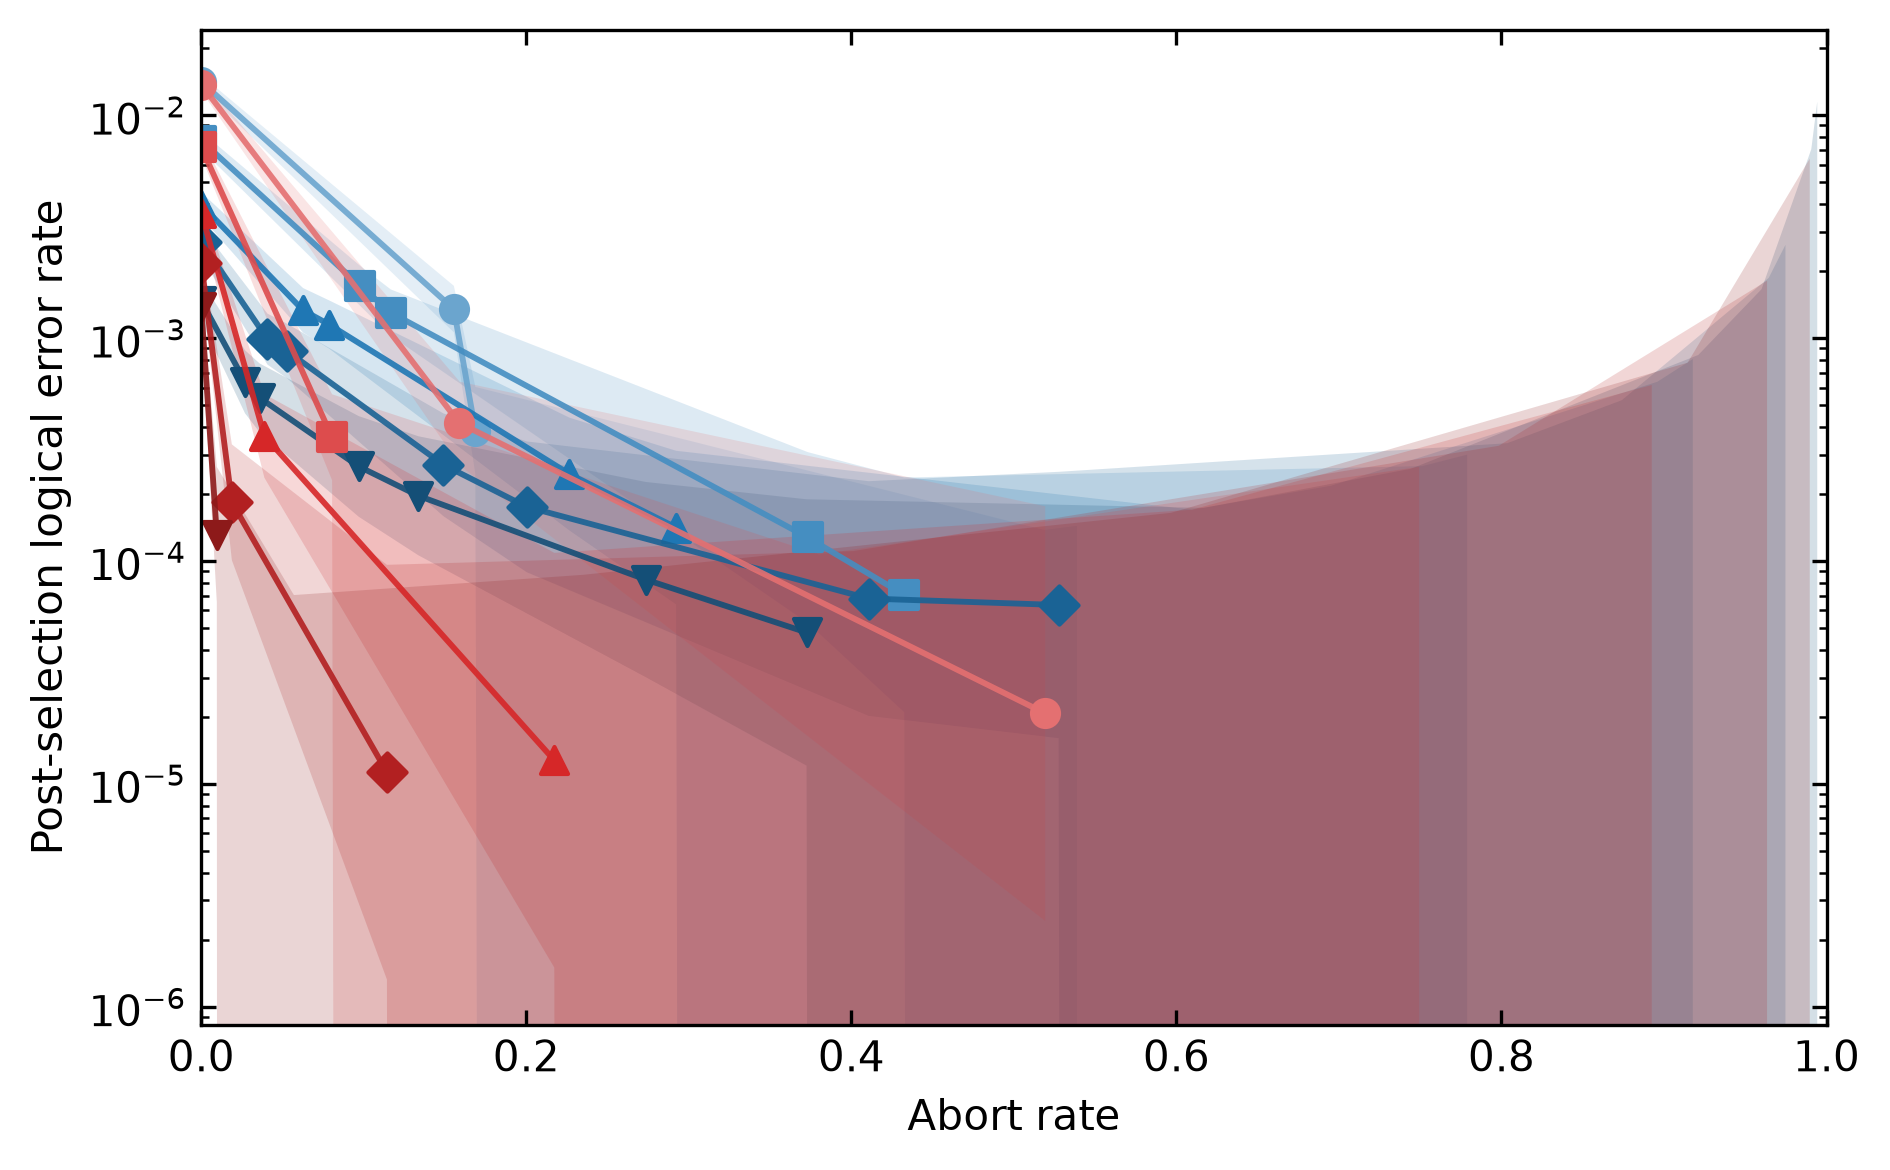

,threshold,abort_rate,retained_shots,retained_failures,residual_logical_error_rate,low,high,distance,decoder_type,metric
0,3.18,0.00000,100000,1413,0.014130,0.013200,0.015124,5,concat_mwpm,swim_distance
1,6.36,0.15543,84457,114,0.001350,0.001061,0.001717,5,concat_mwpm,swim_distance
2,9.53,0.16866,83134,32,0.000385,0.000245,0.000605,5,concat_mwpm,swim_distance
3,12.71,0.51867,48133,0,0.000000,0.000000,0.000138,5,concat_mwpm,swim_distance
4,15.89,0.53885,46115,0,0.000000,0.000000,0.000144,5,concat_mwpm,swim_distance


In [5]:
fig_postselection, ax_postselection = manuscript_axes()
fig_postselection, postselection_table = run.plot_postselection(
    metrics=metrics, filter=filters, group_by=groups,
    round_digits=round_digits, yscale=postselection_yscale,
    xlim=postselection_xlim, ax=ax_postselection,
)
fig_postselection.tight_layout()
display(fig_postselection)
plt.close(fig_postselection)
postselection_table.head()


## Separate legends and manuscript export

Legends are independent Matplotlib figures, one for the blue/red metric hues and one for the paired distance gradients and markers rather than one Cartesian-product legend. The decoder-type legend is intentionally absent when the selected data contain only one decoder type. Edit `legend_layout` to change the size and column count of each legend without changing the main axes. The export cell writes vector PDF and 300 dpi PNG assets, data tables, an editable manuscript TeX snippet, and a dedicated standalone TeX composition to this run's `analysis/` directory. The standalone source combines all three panels and every generated legend into one PDF and one 300 dpi PNG.


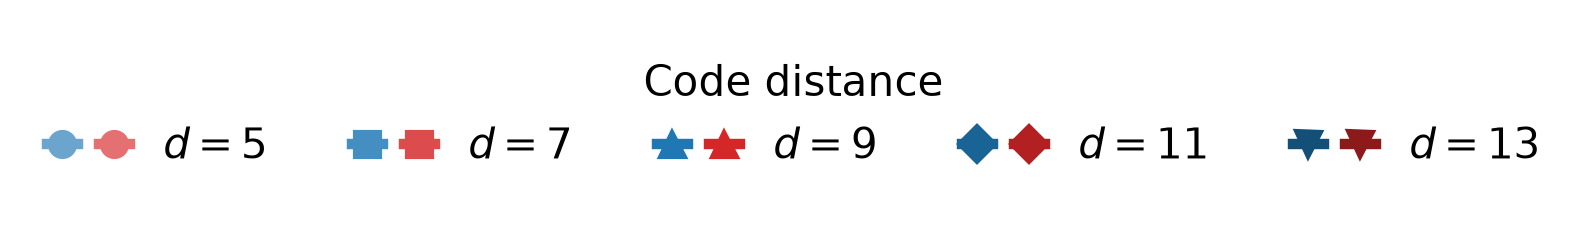

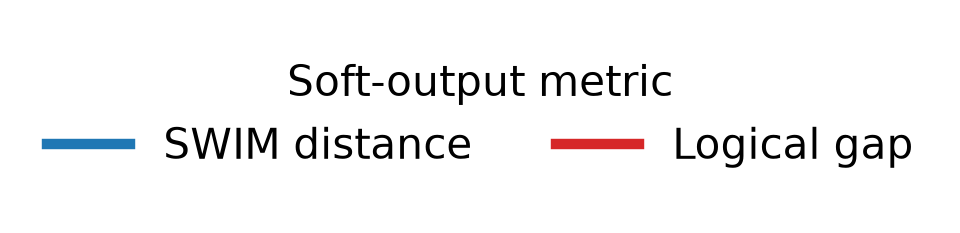

Manuscript assets: /home/quantum_teresheys/workspace/color_code_softoutput/results/bitflip_swim/26_09_30_17_48_23_a219af0b/analysis
TeX snippet: /home/quantum_teresheys/workspace/color_code_softoutput/results/bitflip_swim/26_09_30_17_48_23_a219af0b/analysis/swim_distance_vs_logical_gap_figure.tex


In [6]:
legends = run.plot_legends(distribution_table, **legend_options)
legend_layout = {
    "distance": (5.0, 0.75),
    "metric": (3.5, 0.75),
    "decoder_type": (4.0, 0.75),
    "logical_error": (3.0, 0.75),
}
for name, (legend_figure, legend_axes) in legends.items():
    width, height = legend_layout[name]
    legend_figure.set_size_inches(width, height)
    display(legend_figure)
    plt.close(legend_figure)

stem = "_vs_".join(metrics)
output_dir = run_directory / "analysis"
main_figures = {
    f"{stem}_distribution": fig_distribution,
    f"{stem}_conditional_ler": fig_conditional,
    f"{stem}_postselection": fig_postselection,
}
legend_figures = {f"{stem}_legend_{name}": pair[0] for name, pair in legends.items()}
all_figures = {**main_figures, **legend_figures}
if save_figures:
    output_dir.mkdir(parents=True, exist_ok=True)
    for name, figure in all_figures.items():
        for extension in export_formats:
            figure.savefig(output_dir / f"{name}.{extension}", dpi=figure_dpi,
                           bbox_inches="tight", pad_inches=0.03)
    distribution_table.to_csv(output_dir / f"{stem}_distribution.csv", index=False)
    conditional_table.to_csv(output_dir / f"{stem}_conditional_ler.csv", index=False)
    postselection_table.to_csv(output_dir / f"{stem}_postselection.csv", index=False)

    # Include this editable snippet from a manuscript whose graphics path
    # points at output_dir. Existing manual TeX edits are preserved.
    legend_tex = "\\quad\n".join(
        rf"\includegraphics[height=0.45in]{{{name}.pdf}}"
        for name in legend_figures
    )
    tex_path = output_dir / f"{stem}_figure.tex"
    if not tex_path.exists():
        tex_path.write_text(
            "\n".join([
                r"% Generated by workflow_swim_soft_output.ipynb; edit freely.",
                r"\begin{figure*}[t]",
                r"  \centering",
                rf"  \includegraphics[width=0.49\textwidth]{{{stem}_distribution.pdf}}%",
                rf"  \hfill\includegraphics[width=0.49\textwidth]{{{stem}_conditional_ler.pdf}}\\",
                rf"  \includegraphics[width=0.49\textwidth]{{{stem}_postselection.pdf}}\\[-1mm]",
                rf"  {legend_tex}\\",
                r"  \caption{Distribution, conditional logical error probability, and post-selection performance for the SWIM-distance proxy and comparative logical gap. Blue denotes SWIM distance and red denotes logical gap; darker shades and marker shapes denote larger code distances. Shaded regions are 99\% Wilson intervals.}",
                rf"  \label{{fig:{stem}}}",
                r"\end{figure*}",
                "",
            ]), encoding="utf-8"
        )

    # Captionless, self-contained composition: legends on top, two panels
    # in the first row and post-selection centered below. The editable TeX
    # is created once; every rerun recompiles its current contents.
    standalone_tex = output_dir / f"{stem}_standalone.tex"
    if not standalone_tex.exists():
        legend_names = list(legends)
        legend_weights = {"distance": 5.0, "metric": 3.0,
                          "decoder_type": 4.0, "logical_error": 3.0}
        legend_gap = 0.015
        usable_width = 0.98 - legend_gap * (len(legend_names) - 1)
        total_weight = sum(legend_weights[name] for name in legend_names)
        legend_blocks = []
        for name in legend_names:
            width = usable_width * legend_weights[name] / total_weight
            legend_blocks.append("\n".join([
                rf"    \begin{{minipage}}[t]{{{width:.4f}\linewidth}}",
                r"        \centering\vspace{0pt}%",
                rf"        \includegraphics[width=\linewidth,trim={{2.16bp 2.16bp 2.16bp 2.16bp}},clip]{{{stem}_legend_{name}.pdf}}",
                r"    \end{minipage}%",
            ]))
        legend_row = ("\n" + r"    \hspace{\SoftOutputLegendGap}%" + "\n").join(legend_blocks)
        standalone_tex.write_text("\n".join([
            r"\documentclass[border=0pt]{standalone}",
            r"\usepackage{graphicx}",
            r"\newcommand{\SoftOutputCanvasWidth}{178mm}",
            rf"\newcommand{{\SoftOutputLegendGap}}{{{legend_gap:.3f}\linewidth}}",
            r"\newcommand{\SoftOutputPanelWidth}{0.49\linewidth}",
            r"\newcommand{\SoftOutputVerticalGap}{1mm}",
            r"\begin{document}",
            r"\begin{minipage}{\SoftOutputCanvasWidth}",
            r"    \centering",
            legend_row,
            r"    \par\nointerlineskip\vspace{\SoftOutputVerticalGap}%",
            r"    \begin{minipage}[t]{\SoftOutputPanelWidth}",
            r"        \centering\vspace{0pt}%",
            rf"        \includegraphics[width=\linewidth,trim={{2.16bp 2.16bp 2.16bp 2.16bp}},clip]{{{stem}_distribution.pdf}}",
            r"    \end{minipage}\hfill%",
            r"    \begin{minipage}[t]{\SoftOutputPanelWidth}",
            r"        \centering\vspace{0pt}%",
            rf"        \includegraphics[width=\linewidth,trim={{2.16bp 2.16bp 2.16bp 2.16bp}},clip]{{{stem}_conditional_ler.pdf}}",
            r"    \end{minipage}%",
            r"    \par\nointerlineskip\vspace{\SoftOutputVerticalGap}%",
            r"    \begin{minipage}[t]{\SoftOutputPanelWidth}",
            r"        \centering\vspace{0pt}%",
            rf"        \includegraphics[width=\linewidth,trim={{2.16bp 2.16bp 2.16bp 2.16bp}},clip]{{{stem}_postselection.pdf}}",
            r"    \end{minipage}%",
            r"\end{minipage}",
            r"\end{document}",
            "",
        ]), encoding="utf-8")
    latex = subprocess.run(
        ["pdflatex", "-interaction=nonstopmode", "-halt-on-error",
         standalone_tex.name], cwd=output_dir, check=True, capture_output=True, text=True,
    )
    standalone_pdf = standalone_tex.with_suffix(".pdf")
    subprocess.run(
        ["pdftocairo", "-png", "-r", str(figure_dpi), "-singlefile",
         standalone_pdf.name, standalone_pdf.stem],
        cwd=output_dir, check=True, capture_output=True, text=True,
    )
    print("Manuscript assets:", output_dir)
    print("TeX snippet:", tex_path)
    print("Standalone TeX/PDF/PNG:", standalone_tex)
